# KF and EKF: A Realistic Mixed-Rate Sensor Fusion Example

This notebook walks through a realistic 2D robot/vehicle localization problem using:

- a **linear Kalman Filter** for a constant-velocity model,
- an **Extended Kalman Filter** for IMU + heading + wheel encoder + GPS fusion,
- asynchronous sensor measurements arriving at different rates.

The example is intentionally realistic but still compact enough to study.

## Scenario

We model a small autonomous ground robot with these sensors:

| Sensor | Approx. rate | Measurement |
|---|---:|---|
| IMU | 100 Hz | forward acceleration and yaw rate |
| Wheel encoder | 20 Hz | forward speed |
| GPS | 1 Hz | global 2D position |

The EKF uses fast IMU prediction and slower correction measurements.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 2. Utility Functions

We need a small angle wrapping function because heading angles live on a circle.

For example, the difference between `179°` and `-179°` should be `2°`, not `358°`.

In [2]:
def wrap_angle(a):
    """Wrap angle to [-pi, pi]."""
    return (a + np.pi) % (2 * np.pi) - np.pi


def rot2(theta):
    """2D rotation matrix."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]])

## 3. Simulate a Ground-Truth Robot Trajectory

The true robot moves in 2D. It has:

- position $(p_x, p_y)$
- velocity $(v_x, v_y)$,
- heading $\theta$.

We drive it using a time-varying forward acceleration $a$ and yaw rate $\omega$.

$$
    p_x^+ = p_x + v_x\Delta t + \frac{1}{2}a\cos\theta\Delta t^2 
$$
$$
    p_y^+ = p_y + v_y\Delta t + \frac{1}{2}a\sin\theta\Delta t^2 
$$
$$
    v_x^+ = v_x + a\cos\theta\Delta t
$$
$$
    v_y^+ = v_y + a\sin\theta\Delta t
$$
$$
    \theta^+ = \theta + \omega\Delta t
$$

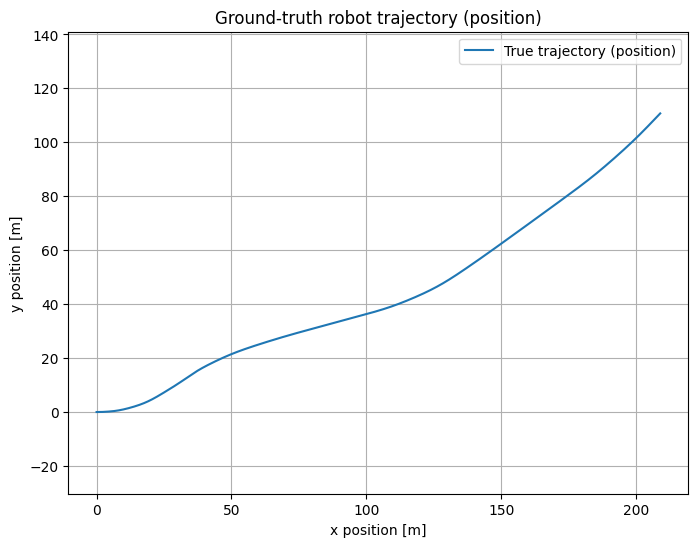

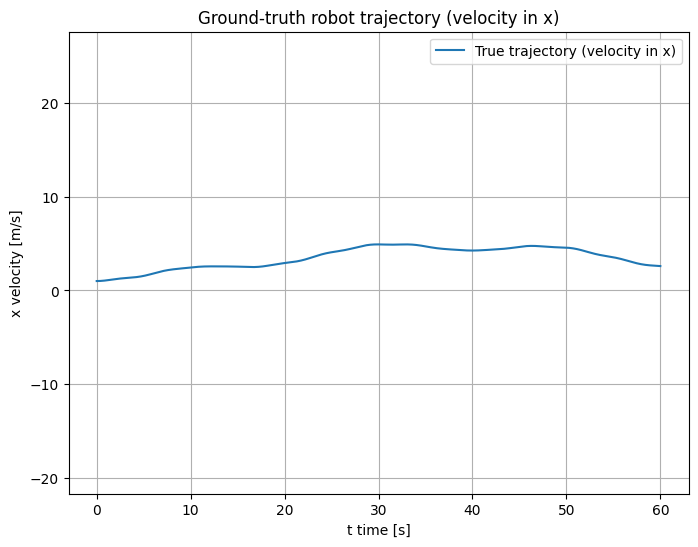

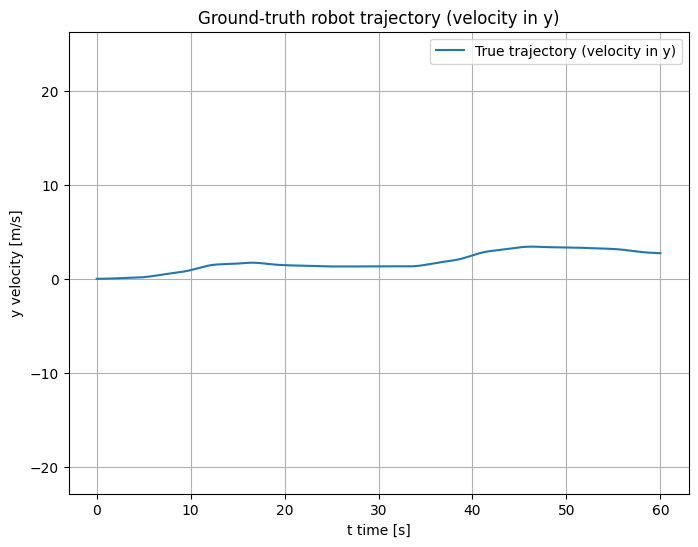

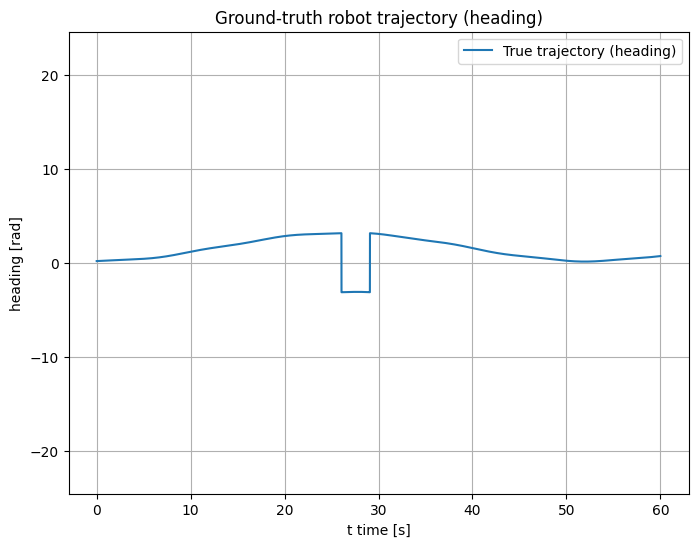

In [3]:
dt_truth = 0.01
T = 60.0
t = np.arange(0.0, T + dt_truth, dt_truth)
N = len(t)

truth = np.zeros((N, 5))  # px, py, vx, vy, theta

def true_forward_accel(time):
    # Mostly gentle acceleration, with oscillations.
    return 0.25 * np.sin(0.20 * time) + 0.08 * np.sin(1.30 * time)

def true_yaw_rate(time):
    # Curving path with changing turn rate.
    return 0.18 * np.sin(0.12 * time) + 0.04 * np.cos(0.70 * time)

truth[0] = np.array([0.0, 0.0, 1.0, 0.0, np.deg2rad(10.0)])

for k in range(1, N):
    px, py, vx, vy, theta = truth[k-1]
    a = true_forward_accel(t[k-1])
    omega = true_yaw_rate(t[k-1])

    ax = a * np.cos(theta)
    ay = a * np.sin(theta)

    px_new = px + vx * dt_truth + 0.5 * ax * dt_truth**2
    py_new = py + vy * dt_truth + 0.5 * ay * dt_truth**2
    vx_new = vx + ax * dt_truth
    vy_new = vy + ay * dt_truth
    theta_new = wrap_angle(theta + omega * dt_truth)

    truth[k] = np.array([px_new, py_new, vx_new, vy_new, theta_new])

plt.figure(figsize=(8, 6))
plt.plot(truth[:, 0], truth[:, 1], label="True trajectory (position)")
plt.axis("equal")
plt.xlabel("x position [m]")
plt.ylabel("y position [m]")
plt.title("Ground-truth robot trajectory (position)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(t, truth[:, 2], label="True trajectory (velocity in x)")
plt.axis("equal")
plt.xlabel('t time [s]')
plt.ylabel("x velocity [m/s]")
plt.title("Ground-truth robot trajectory (velocity in x)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(t, truth[:, 3], label="True trajectory (velocity in y)")
plt.axis("equal")
plt.xlabel('t time [s]')
plt.ylabel("y velocity [m/s]")
plt.title("Ground-truth robot trajectory (velocity in y)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(t, truth[:, 4], label="True trajectory (heading)")
plt.axis("equal")
plt.xlabel('t time [s]')
plt.ylabel("heading [rad]")
plt.title("Ground-truth robot trajectory (heading)")
plt.legend()
plt.grid(True)
plt.show()



## 4. Generate Mixed-Rate Sensor Measurements

We simulate three sensors:

### IMU, 100 Hz

Measures:

$$
a_m = a + b_a + n_a
$$

$$
\omega_m = \omega + b_\omega + n_\omega
$$

where $b_a$ and $b_\omega$ are sensor biases, $n_\cdot$ are corresponding noises.

### Wheel encoder, 20 Hz

Measures forward speed:

$$
v_\text{forward} = v_x \cos\theta + v_y \sin\theta
$$

### GPS, 1 Hz

Measures global position:

$$
z_\text{gps} =
\begin{bmatrix}
p_x \\
p_y
\end{bmatrix}
+
\text{noise}
$$

The filter processes all events in timestamp order.

In [4]:
rng = np.random.default_rng(7)

# True sensor biases.
true_ba = 0.04       # m/s^2
true_bw = 0.008      # rad/s

# Sensor noise standard deviations.
sigma_accel = 0.08       # m/s^2
sigma_gyro = 0.01        # rad/s
sigma_wheel = 0.08       # m/s
sigma_gps = 1.2          # m

imu_rate = 100.0
wheel_rate = 20.0
gps_rate = 1.0

imu_times = np.arange(0.0, T + 1e-9, 1 / imu_rate)
wheel_times = np.arange(0.0, T + 1e-9, 1 / wheel_rate)
gps_times = np.arange(0.0, T + 1e-9, 1 / gps_rate)

def interp_truth(true_state, time):
    """Nearest-neighbor truth lookup for simplicity."""
    idx = int(round(time / dt_truth))
    idx = np.clip(idx, 0, N - 1)
    return true_state[idx]

events = []

for time in imu_times:
    px, py, vx, vy, theta = interp_truth(truth, time)
    a = true_forward_accel(time)
    omega = true_yaw_rate(time)

    am = a + true_ba + rng.normal(0.0, sigma_accel)
    wm = omega + true_bw + rng.normal(0.0, sigma_gyro)

    events.append({
        "time": float(time),
        "type": "imu",
        "z": np.array([am, wm])
    })

for time in wheel_times:
    px, py, vx, vy, theta = interp_truth(truth, time)
    v_forward = vx * np.cos(theta) + vy * np.sin(theta)
    z = v_forward + rng.normal(0.0, sigma_wheel)

    events.append({
        "time": float(time),
        "type": "wheel",
        "z": np.array([z])
    })

for time in gps_times:
    px, py, vx, vy, theta = interp_truth(truth, time)
    z = np.array([px, py]) + rng.normal(0.0, sigma_gps, size=2)

    # Inject one GPS outlier to show a real-world problem.
    if abs(time - 35.0) < 1e-9:
        z += np.array([9.0, -7.0])

    events.append({
        "time": float(time),
        "type": "gps",
        "z": z
    })

events = sorted(events, key=lambda e: (e["time"], {"imu": 0, "wheel": 1, "gps": 2}[e["type"]]))

len(events), events[:5]

(7263,
 [{'time': 0.0, 'type': 'imu', 'z': array([0.0401, 0.051 ])},
  {'time': 0.0, 'type': 'wheel', 'z': array([1.1642])},
  {'time': 0.0, 'type': 'gps', 'z': array([ 1.3009, -0.0196])},
  {'time': 0.01, 'type': 'imu', 'z': array([0.0196, 0.0393])},
  {'time': 0.02, 'type': 'imu', 'z': array([0.0067, 0.0385])}])

## 5. Linear Kalman Filter Baseline

The linear KF uses a constant-velocity state:

$$
x =
\begin{bmatrix}
p_x & p_y & v_x & v_y
\end{bmatrix}^T
$$

Prediction:

$$
x_{k+1} =
F x_k + w_k
$$

where

$$
F =
\begin{bmatrix}
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
$$

This filter uses GPS position updates only. It deliberately ignores IMU, heading, and wheel speed.

In [5]:
def run_linear_kf(events):
    # State: px, py, vx, vy
    x = np.array([0.0, 0.0, 0.5, 0.0])
    P = np.diag([10.0, 10.0, 5.0, 5.0])

    last_time = 0.0
    estimates = []

    # Process acceleration noise.
    sigma_process_accel = 0.8

    H_gps = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
    ])
    R_gps = np.diag([sigma_gps**2, sigma_gps**2])

    for e in events:
        time = e["time"]
        dt = time - last_time
        if dt < -1e-12:
            raise ValueError("Events must be sorted by time")

        if dt > 0:
            F = np.array([
                [1, 0, dt, 0],
                [0, 1, 0, dt],
                [0, 0, 1, 0],
                [0, 0, 0, 1],
            ])

            # Discrete white-acceleration process noise.
            q = sigma_process_accel**2
            Q1 = np.array([
                [dt**4 / 4, dt**3 / 2],
                [dt**3 / 2, dt**2],
            ]) * q
            Q = np.array([
                [Q1[0,0], 0,       Q1[0,1], 0],
                [0,       Q1[0,0], 0,       Q1[0,1]],
                [Q1[1,0], 0,       Q1[1,1], 0],
                [0,       Q1[1,0], 0,       Q1[1,1]],
            ])

            x = F @ x
            P = F @ P @ F.T + Q
            last_time = time

        if e["type"] == "gps":
            z = e["z"]
            y = z - H_gps @ x
            S = H_gps @ P @ H_gps.T + R_gps
            K = P @ H_gps.T @ np.linalg.inv(S)
            x = x + K @ y
            P = (np.eye(4) - K @ H_gps) @ P

        estimates.append((time, x.copy(), P.copy()))

    return estimates


kf_estimates = run_linear_kf(events)

kf_t = np.array([e[0] for e in kf_estimates])
kf_x = np.array([e[1] for e in kf_estimates])
kf_P = np.array([e[2] for e in kf_estimates])

## 6. Extended Kalman Filter

The EKF state is:

$$
x =
\begin{bmatrix}
p_x &
p_y &
v_x &
v_y &
\theta &
b_a &
b_\omega
\end{bmatrix}^T
$$

The IMU prediction is nonlinear because forward acceleration is measured in the body frame and must be rotated into the world frame:

$$
a_x = (a_m - b_a)\cos\theta
$$

$$
a_y = (a_m - b_a)\sin\theta
$$

Wheel speed is also nonlinear:

$$
h_\text{wheel}(x) =
v_x\cos\theta + v_y\sin\theta
$$

GPS is linear:

$$
h_\text{gps}(x) =
\begin{bmatrix}
p_x \\
p_y
\end{bmatrix}
$$

In [6]:
def ekf_predict(x, P, imu_z, dt):
    """EKF prediction using IMU measurement as input."""
    am, wm = imu_z
    px, py, vx, vy, theta, ba, bw = x

    a = am - ba
    omega = wm - bw
    c, s = np.cos(theta), np.sin(theta)

    # Nonlinear prediction.
    x_pred = x.copy()
    x_pred[0] = px + vx * dt + 0.5 * a * c * dt**2
    x_pred[1] = py + vy * dt + 0.5 * a * s * dt**2
    x_pred[2] = vx + a * c * dt
    x_pred[3] = vy + a * s * dt
    x_pred[4] = wrap_angle(theta + omega * dt)
    x_pred[5] = ba
    x_pred[6] = bw

    # Jacobian F = df/dx.
    F = np.eye(7)
    F[0, 2] = dt
    F[1, 3] = dt

    F[0, 4] = -0.5 * a * s * dt**2
    F[1, 4] =  0.5 * a * c * dt**2
    F[2, 4] = -a * s * dt
    F[3, 4] =  a * c * dt

    F[0, 5] = -0.5 * c * dt**2
    F[1, 5] = -0.5 * s * dt**2
    F[2, 5] = -c * dt
    F[3, 5] = -s * dt

    F[4, 6] = -dt

    # Process noise. This is a practical tuning matrix.
    # It includes uncertainty in acceleration, gyro, and bias random walk.
    sigma_model_accel = 0.15
    sigma_model_gyro = 0.02
    sigma_ba_rw = 0.004
    sigma_bw_rw = 0.001

    Q = np.diag([
        0.05 * dt**2,
        0.05 * dt**2,
        sigma_model_accel**2 * dt,
        sigma_model_accel**2 * dt,
        sigma_model_gyro**2 * dt,
        sigma_ba_rw**2 * dt,
        sigma_bw_rw**2 * dt,
    ])

    P_pred = F @ P @ F.T + Q
    return x_pred, P_pred


def ekf_update(x, P, z, h, H, R, angle_index=None, gate_threshold=None):
    """Generic EKF update with optional innovation gating."""
    z_pred = h(x)
    y = z - z_pred

    if angle_index is not None:
        y[angle_index] = wrap_angle(y[angle_index])

    Hx = H(x)
    S = Hx @ P @ Hx.T + R
    nis = float(y.T @ np.linalg.inv(S) @ y)

    if gate_threshold is not None and nis > gate_threshold:
        return x, P, nis, True

    K = P @ Hx.T @ np.linalg.inv(S)
    x_new = x + K @ y
    x_new[4] = wrap_angle(x_new[4])

    I = np.eye(P.shape[0])
    # Joseph form for numerical stability.
    P_new = (I - K @ Hx) @ P @ (I - K @ Hx).T + K @ R @ K.T

    return x_new, P_new, nis, False


def gps_h(x):
    return x[:2]

def gps_H(x):
    H = np.zeros((2, 7))
    H[0, 0] = 1.0
    H[1, 1] = 1.0
    return H

def wheel_h(x):
    px, py, vx, vy, theta, ba, bw = x
    return np.array([vx * np.cos(theta) + vy * np.sin(theta)])

def wheel_H(x):
    px, py, vx, vy, theta, ba, bw = x
    H = np.zeros((1, 7))
    H[0, 2] = np.cos(theta)
    H[0, 3] = np.sin(theta)
    H[0, 4] = -vx * np.sin(theta) + vy * np.cos(theta)
    return H

## 7. Run the EKF

Important detail: the EKF predicts with the most recent IMU reading and updates whenever a wheel or GPS measurement arrives.

This is an event-based mixed-rate filter: every measurement has a timestamp, and the filter propagates to that timestamp before applying the appropriate update.

In [7]:
def run_ekf(events, use_gps_gating=True):
    # State: px, py, vx, vy, theta, accel_bias, gyro_bias
    x = np.array([0.0, 0.0, 0.8, 0.0, np.deg2rad(5.0), 0.0, 0.0])
    P = np.diag([
        5.0**2, 5.0**2,
        1.0**2, 1.0**2,
        np.deg2rad(20.0)**2,
        0.2**2,
        0.05**2,
    ])

    R_gps = np.diag([sigma_gps**2, sigma_gps**2])
    R_wheel = np.array([[sigma_wheel**2]])

    last_time = 0.0
    last_imu = np.array([0.0, 0.0])

    estimates = []
    rejected_gps = []
    gps_nis_values = []

    for e in events:
        time = e["time"]
        dt = time - last_time

        # Predict to current event time using the last available IMU reading.
        if dt > 0:
            x, P = ekf_predict(x, P, last_imu, dt)
            last_time = time

        if e["type"] == "imu":
            # Use this IMU reading for future propagation.
            last_imu = e["z"]

        elif e["type"] == "wheel":
            x, P, nis, rejected = ekf_update(
                x, P,
                z=e["z"],
                h=wheel_h,
                H=wheel_H,
                R=R_wheel,
                gate_threshold=9.0
            )

        elif e["type"] == "gps":
            gate = 9.21 if use_gps_gating else None  # approx chi-square 99% threshold for 2D
            x, P, nis, rejected = ekf_update(
                x, P,
                z=e["z"],
                h=gps_h,
                H=gps_H,
                R=R_gps,
                gate_threshold=gate
            )
            gps_nis_values.append((time, nis))
            if rejected:
                rejected_gps.append((time, e["z"].copy(), nis))

        estimates.append((time, x.copy(), P.copy()))

    return estimates, rejected_gps, gps_nis_values


ekf_estimates, rejected_gps, gps_nis_values = run_ekf(events, use_gps_gating=True)

ekf_t = np.array([e[0] for e in ekf_estimates])
ekf_x = np.array([e[1] for e in ekf_estimates])
ekf_P = np.array([e[2] for e in ekf_estimates])

rejected_gps[:5], len(rejected_gps)

([(33.0, array([93.9875, 38.9676]), 11.720862169140243),
  (35.0, array([114.8283,  31.6783]), 44.74250482100482)],
 2)

## 8. Compare Linear KF and EKF Against Ground Truth

The linear KF uses only GPS and a constant-velocity model.

The EKF uses:

- IMU for prediction,
- wheel speed for velocity correction,
- GPS for position correction,
- bias states for IMU drift compensation.

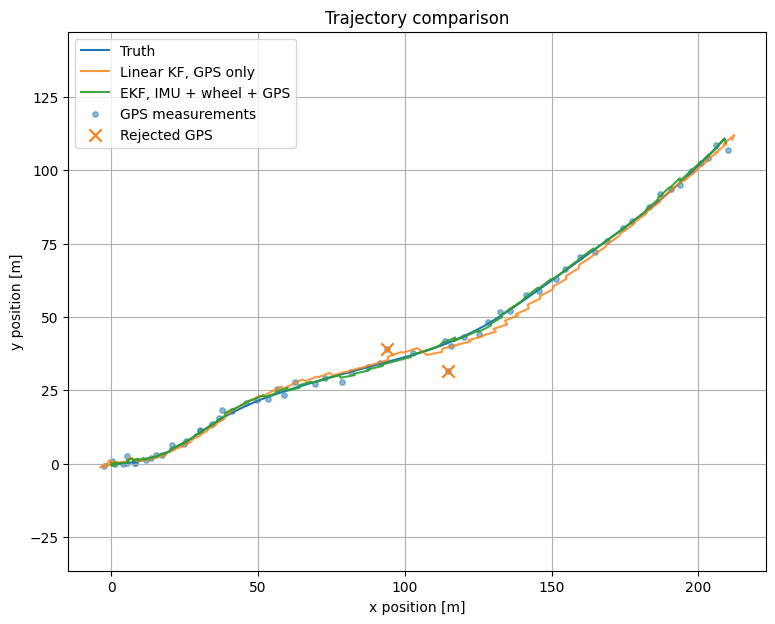

In [8]:
# Interpolate truth at estimate timestamps using nearest neighbor.
def truth_at_times(times):
    idx = np.clip(np.round(times / dt_truth).astype(int), 0, N - 1)
    return truth[idx]

truth_kf = truth_at_times(kf_t)
truth_ekf = truth_at_times(ekf_t)

plt.figure(figsize=(9, 7))
plt.plot(truth[:, 0], truth[:, 1], label="Truth")
plt.plot(kf_x[:, 0], kf_x[:, 1], label="Linear KF, GPS only", alpha=0.8)
plt.plot(ekf_x[:, 0], ekf_x[:, 1], label="EKF, IMU + wheel + GPS", alpha=0.9)

gps_points = np.array([e["z"] for e in events if e["type"] == "gps"])
plt.scatter(gps_points[:, 0], gps_points[:, 1], s=15, label="GPS measurements", alpha=0.5)

if rejected_gps:
    rgps = np.array([item[1] for item in rejected_gps])
    plt.scatter(rgps[:, 0], rgps[:, 1], s=80, marker="x", label="Rejected GPS")

plt.axis("equal")
plt.xlabel("x position [m]")
plt.ylabel("y position [m]")
plt.title("Trajectory comparison")
plt.legend()
plt.grid(True)
plt.show()

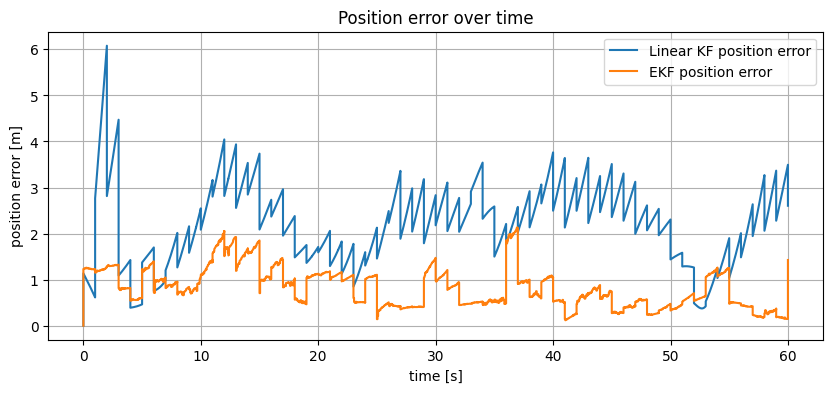

Linear KF mean position error: 2.227 m
EKF mean position error:       0.819 m
Linear KF final position error: 2.605 m
EKF final position error:       1.427 m


In [9]:
kf_pos_err = np.linalg.norm(kf_x[:, :2] - truth_kf[:, :2], axis=1)
ekf_pos_err = np.linalg.norm(ekf_x[:, :2] - truth_ekf[:, :2], axis=1)

plt.figure(figsize=(10, 4))
plt.plot(kf_t, kf_pos_err, label="Linear KF position error")
plt.plot(ekf_t, ekf_pos_err, label="EKF position error")
plt.xlabel("time [s]")
plt.ylabel("position error [m]")
plt.title("Position error over time")
plt.legend()
plt.grid(True)
plt.show()

print(f"Linear KF mean position error: {np.mean(kf_pos_err):.3f} m")
print(f"EKF mean position error:       {np.mean(ekf_pos_err):.3f} m")
print(f"Linear KF final position error: {kf_pos_err[-1]:.3f} m")
print(f"EKF final position error:       {ekf_pos_err[-1]:.3f} m")

## 9. Bias Estimation

One reason EKFs are widely used for navigation is that they can estimate slowly varying nuisance parameters, such as IMU biases.

Here we compare estimated accelerometer and gyro biases against the true simulated biases.

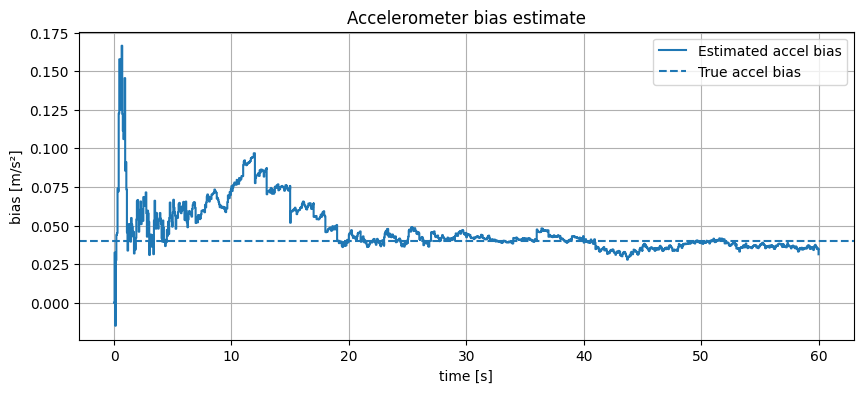

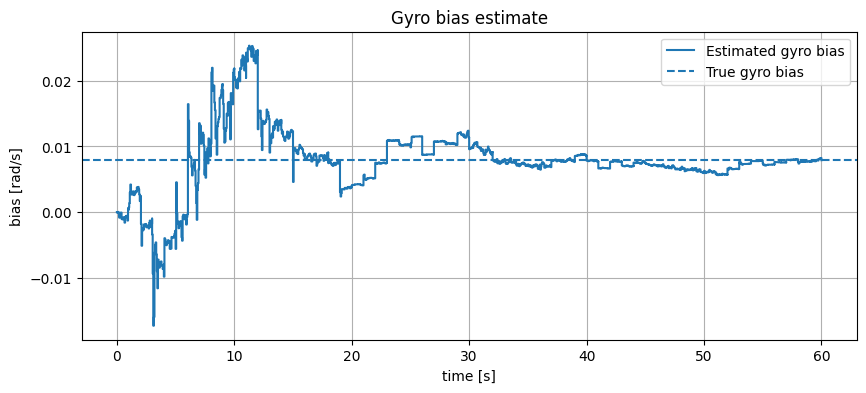

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(ekf_t, ekf_x[:, 5], label="Estimated accel bias")
plt.axhline(true_ba, linestyle="--", label="True accel bias")
plt.xlabel("time [s]")
plt.ylabel("bias [m/s²]")
plt.title("Accelerometer bias estimate")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(ekf_t, ekf_x[:, 6], label="Estimated gyro bias")
plt.axhline(true_bw, linestyle="--", label="True gyro bias")
plt.xlabel("time [s]")
plt.ylabel("bias [rad/s]")
plt.title("Gyro bias estimate")
plt.legend()
plt.grid(True)
plt.show()

## 10. Innovation Gating for GPS Outliers

A realistic system should not blindly accept every measurement.

For GPS, we can compute the normalized innovation squared:

$$
d^2 = y^T S^{-1} y
$$

where:

- $y = z - h(x)$ is the innovation,
- $S = HPH^T + R$ is the innovation covariance.

If $d^2$ is too large, the measurement is statistically suspicious.

In this notebook, we injected a GPS outlier at `t = 35 s`.

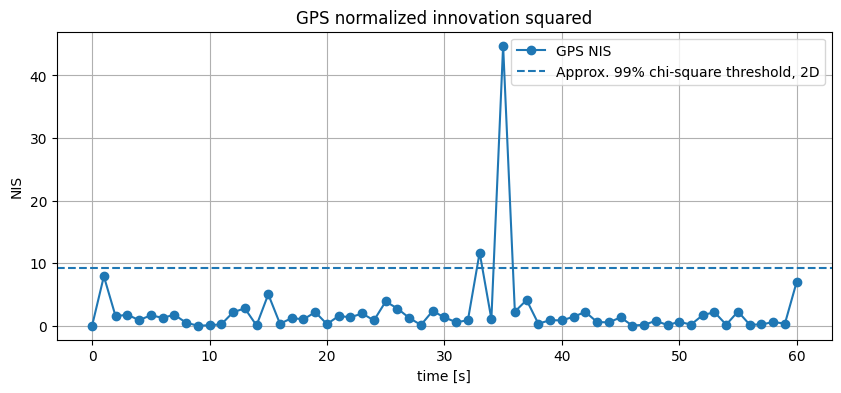

Rejected GPS measurements:
  t=33.0s, z=[93.9875 38.9676], NIS=11.72
  t=35.0s, z=[114.8283  31.6783], NIS=44.74


In [11]:
gps_nis = np.array(gps_nis_values)

plt.figure(figsize=(10, 4))
plt.plot(gps_nis[:, 0], gps_nis[:, 1], marker="o", label="GPS NIS")
plt.axhline(9.21, linestyle="--", label="Approx. 99% chi-square threshold, 2D")
plt.xlabel("time [s]")
plt.ylabel("NIS")
plt.title("GPS normalized innovation squared")
plt.legend()
plt.grid(True)
plt.show()

print("Rejected GPS measurements:")
for time, z, nis in rejected_gps:
    print(f"  t={time:.1f}s, z={z}, NIS={nis:.2f}")

## 11. What This Example Teaches

### Linear KF

The linear KF is appropriate when the system can be written as:

$$
x_{k+1} = F x_k + B u_k + w_k
$$

$$
z_k = H x_k + v_k
$$

In this notebook, the GPS-only constant-velocity tracker is linear.

### EKF

The EKF is used when the system has nonlinear motion or measurement models:

$$
x_{k+1} = f(x_k, u_k) + w_k
$$

$$
z_k = h(x_k) + v_k
$$

In this notebook, the EKF is needed because:

- IMU acceleration is measured in the robot frame and must be rotated into the world frame.
- wheel encoder speed depends on heading.
- heading angles need wraparound handling.
- bias estimation is naturally added to the state.

### Mixed-rate sensors

Measurements arrive asynchronously:

```text
IMU:     100 Hz
Wheel:    20 Hz
GPS:       1 Hz
```

The filter processes them in timestamp order:

```text
predict to event time
if measurement is available:
    update with that sensor's model
```

This is the most common architecture for real-world Kalman-filter-based sensor fusion.

## 12. Suggested Extensions

To make the notebook more realistic, you could add:

1. delayed GPS or camera measurements with a history buffer,
2. wheel slip detection and adaptive wheel covariance,
3. magnetometer heading updates,
4. LiDAR or camera pose updates,
5. Unscented Kalman Filter comparison,
6. full 3D state with quaternion orientation,
7. covariance consistency checks using NEES/NIS.